# Default Prediction Model

## Objective

This part builds machine-learning models to predict whether a loan may default.

I compare two model types:

- Logistic Regression as a simple baseline
- Random Forest as a stronger nonlinear model

I also keep two feature sets:

- Approval-style features: customer and loan information available before or near loan approval
- Monitoring features: approval-style features plus current repayment-warning signals like missed payments and days past due

The train/test split is done by `customer_id`, so the same borrower cannot appear in both training and testing data.


## 1. Import Libraries and Load Data


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import StratifiedGroupKFold, RandomizedSearchCV
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

project_dir = Path.cwd()
if project_dir.name == "notebooks":
    project_dir = project_dir.parent

processed_dir = project_dir / "data" / "processed"
tables_dir = project_dir / "reports" / "tables"
figures_dir = project_dir / "reports" / "figures" / "modeling"
figures_dir.mkdir(parents=True, exist_ok=True)

data_path = processed_dir / "banking_customer_loan_analytics_clean.csv"
loan_df = pd.read_csv(data_path)

loan_df.shape


(11911, 55)

### Data Used

The model uses the clean loan-level dataset. Each row is one loan record, and the target column is `default_flag`.


In [2]:
loan_df[["loan_id", "customer_id", "loan_type", "loan_amount", "repayment_status", "default_flag"]].head()


,loan_id,customer_id,loan_type,loan_amount,repayment_status,default_flag
0,LOAN000001,CUST07874,Education Loan,476245.49,Current,0
1,LOAN000002,CUST05835,Home Loan,2900138.60,Current,0
2,LOAN000003,CUST09330,Home Loan,1647702.57,Current,0
3,LOAN000004,CUST03418,Business Loan,2737180.44,Current,0
4,LOAN000005,CUST07800,Auto Loan,271956.76,Current,0


## 2. Target and Class Balance Check

Before modelling, I check how many loans are default and non-default. I also check this at customer level because one customer can have more than one loan.


In [3]:
loan_target_summary = (
    loan_df["default_flag"]
    .value_counts()
    .rename_axis("default_flag")
    .reset_index(name="loans")
    .sort_values("default_flag")
)
loan_target_summary["loan_pct"] = (loan_target_summary["loans"] / len(loan_df) * 100).round(2)
loan_target_summary["label"] = loan_target_summary["default_flag"].map({0: "Not Default", 1: "Default"})

customer_target = loan_df.groupby("customer_id")["default_flag"].max()
customer_target_summary = (
    customer_target
    .value_counts()
    .rename_axis("default_flag")
    .reset_index(name="customers")
    .sort_values("default_flag")
)
customer_target_summary["customer_pct"] = (customer_target_summary["customers"] / len(customer_target) * 100).round(2)
customer_target_summary["label"] = customer_target_summary["default_flag"].map({0: "No Default Loan", 1: "At Least One Default Loan"})

model_target_summary = pd.DataFrame(
    [
        {
            "level": "Loan",
            "not_default": int(loan_target_summary.loc[loan_target_summary["default_flag"] == 0, "loans"].iloc[0]),
            "default": int(loan_target_summary.loc[loan_target_summary["default_flag"] == 1, "loans"].iloc[0]),
            "total": len(loan_df),
            "default_rate_pct": round(loan_df["default_flag"].mean() * 100, 2),
        },
        {
            "level": "Customer",
            "not_default": int(customer_target_summary.loc[customer_target_summary["default_flag"] == 0, "customers"].iloc[0]),
            "default": int(customer_target_summary.loc[customer_target_summary["default_flag"] == 1, "customers"].iloc[0]),
            "total": len(customer_target),
            "default_rate_pct": round(customer_target.mean() * 100, 2),
        },
    ]
)

model_target_summary.to_csv(tables_dir / "model_default_target_summary.csv", index=False)

print("Loan-level target")
display(loan_target_summary[["label", "loans", "loan_pct"]])

print("Customer-level target")
display(customer_target_summary[["label", "customers", "customer_pct"]])

model_target_summary


Loan-level target


,label,loans,loan_pct
0,Not Default,10433,87.59
1,Default,1478,12.41


Customer-level target


,label,customers,customer_pct
0,No Default Loan,8843,86.03
1,At Least One Default Loan,1436,13.97


,level,not_default,default,total,default_rate_pct
0,Loan,10433,1478,11911,12.41
1,Customer,8843,1436,10279,13.97


### Target Result

At loan level, the model has many more non-default loans than default loans. This is class imbalance.

Because of this, accuracy alone can be misleading. A model can get high accuracy by predicting most loans as not default, but that would not be useful for risk work. I use precision, recall, F1-score, and ROC-AUC along with accuracy.


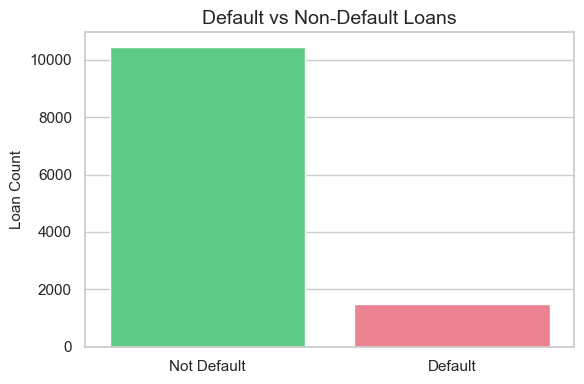

In [4]:
plt.figure(figsize=(6, 4))
sns.barplot(data=loan_target_summary, x="label", y="loans", hue="label", palette=["#4ade80", "#fb7185"], legend=False)
plt.title("Default vs Non-Default Loans")
plt.xlabel("")
plt.ylabel("Loan Count")
plt.tight_layout()
plt.savefig(figures_dir / "target_default_distribution.png", dpi=160)
plt.show()


## 3. Choose Features

I remove fields that would leak the answer into the model.

Removed from model input:

- IDs and names: `loan_id`, `customer_id`, `customer_name`
- final outcome fields: `repayment_status`, `default_flag`
- money outcome field: `expected_loss_amount`
- raw dates: `loan_start_date`, `joined_bank`

I build two feature sets:

- Approval-style features: customer profile, financial position, and loan information
- Monitoring features: approval-style features plus current warning signals


In [5]:
approval_features = [
    "loan_type",
    "loan_amount",
    "loan_term_months",
    "interest_rate",
    "collateral_type",
    "monthly_loan_payment",
    "loan_purpose",
    "credit_score",
    "debt_to_income_ratio",
    "loan_to_value_ratio",
    "age",
    "gender",
    "occupation",
    "employment_status",
    "city",
    "state",
    "banking_relationship",
    "loyalty_classification",
    "annual_income",
    "monthly_income",
    "bank_deposits",
    "checking_balance",
    "savings_balance",
    "credit_card_limit",
    "credit_card_balance",
    "credit_utilization_ratio",
    "business_lending",
    "existing_monthly_debt_payment",
    "total_deposit_balance",
    "deposit_to_income_ratio",
    "customer_tenure_years",
    "loan_to_income_ratio",
    "exposure_after_deposits",
]

monitoring_features = approval_features + [
    "missed_payments_12m",
    "days_past_due",
    "risk_band",
]

target = "default_flag"

print("Approval-style feature count:", len(approval_features))
print("Monitoring feature count:", len(monitoring_features))


Approval-style feature count: 33
Monitoring feature count: 36


## 4. Feature Set Meaning and Leakage Check

This is the important modelling logic.

The target is `default_flag`, so I do not use columns that directly reveal the final outcome, such as `repayment_status`, `default_flag`, or `expected_loss_amount`.

I keep two Random Forest versions because they answer different questions:

- Approval-style: what risk is visible from customer and loan profile?
- Monitoring: which active loans look risky after repayment behavior has started?


In [6]:
feature_set_explanation = pd.DataFrame(
    [
        {
            "feature_set": "Approval-style",
            "main_use": "Loan approval / early risk check",
            "uses_repayment_warning_fields": "No",
            "example_features": "income, credit score, DTI, loan amount, loan type, deposits",
            "important_note": "More realistic before repayment behavior is known",
        },
        {
            "feature_set": "Monitoring",
            "main_use": "Active loan monitoring",
            "uses_repayment_warning_fields": "Yes",
            "example_features": "approval features + missed payments, days past due, risk band",
            "important_note": "Better for finding risky existing loans",
        },
    ]
)

feature_set_explanation.to_csv(tables_dir / "model_feature_set_explanation.csv", index=False)
feature_set_explanation


,feature_set,main_use,uses_repayment_warning_fields,example_features,important_note
0,Approval-style,Loan approval / early risk check,No,"income, credit score, DTI, loan amount, loan t...",More realistic before repayment behavior is known
1,Monitoring,Active loan monitoring,Yes,"approval features + missed payments, days past...",Better for finding risky existing loans


### Leakage Check Result

The approval-style model avoids repayment-warning fields, so it is closer to a before-approval risk check.

The monitoring model includes repayment-warning fields, so it should not be explained as a pure loan-approval model. It is mainly useful after the loan is active.


### Metrics Used

- Precision: when the model says default, how often it is correct
- Recall: out of all actual default loans, how many the model catches
- F1-score: balance between precision and recall
- ROC-AUC: how well the model separates default and non-default loans
- False negatives: actual default loans incorrectly predicted as not default
- False positives: non-default loans incorrectly predicted as default

For banking risk, recall is important because missing a risky loan can be costly. I use accuracy only as a supporting metric, not as the main model-selection metric.


## 5. Customer-Wise Train/Test Split

Customer-wise splitting prevents information from the same borrower appearing in both training and testing data. This gives a more realistic evaluation on unseen customers.

The same train and test customer groups are reused for all four model combinations.


In [7]:
splitter = StratifiedGroupKFold(
    n_splits=4,
    shuffle=True,
    random_state=42,
)

split_target = loan_df[target]
split_groups = loan_df["customer_id"]
train_idx, test_idx = next(splitter.split(loan_df, split_target, split_groups))

train_customers = set(loan_df.loc[train_idx, "customer_id"])
test_customers = set(loan_df.loc[test_idx, "customer_id"])
overlapping_customers = train_customers.intersection(test_customers)

assert train_customers.isdisjoint(test_customers)

split_summary = pd.DataFrame(
    [
        {
            "training_loan_rows": len(train_idx),
            "testing_loan_rows": len(test_idx),
            "unique_training_customers": len(train_customers),
            "unique_testing_customers": len(test_customers),
            "training_default_rate": round(loan_df.loc[train_idx, target].mean() * 100, 2),
            "testing_default_rate": round(loan_df.loc[test_idx, target].mean() * 100, 2),
            "overlapping_customers": len(overlapping_customers),
        }
    ]
)

split_summary


,training_loan_rows,testing_loan_rows,unique_training_customers,unique_testing_customers,training_default_rate,testing_default_rate,overlapping_customers
0,8937,2974,7709,2570,12.34,12.61,0


## 6. Helper Functions

These helper functions keep the modelling code simple. They prepare numeric/categorical columns, tune Random Forest only on the training customers, train either Logistic Regression or Random Forest, and calculate the same metrics for each feature set.

The function does not create a new final test split. It always uses the customer-wise train/test indices created above.


In [8]:
def build_preprocessor(X):
    numeric_features = X.select_dtypes(include=["number", "bool"]).columns.tolist()
    categorical_features = X.select_dtypes(exclude=["number", "bool"]).columns.tolist()

    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features),
            ("cat", categorical_pipeline, categorical_features),
        ]
    )

    return preprocessor, numeric_features, categorical_features


def calculate_metrics(feature_set_name, model_name, y_true, y_pred, y_probability):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "feature_set": feature_set_name,
        "model": model_name,
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "f1_score": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "roc_auc": round(roc_auc_score(y_true, y_probability), 4),
        "false_negatives": int(fn),
        "false_positives": int(fp),
    }


def tune_random_forest_on_training_data(feature_set_name, feature_columns, train_idx):
    X_train_full = loan_df.iloc[train_idx][feature_columns].copy()
    y_train_full = loan_df.iloc[train_idx][target].copy()
    train_groups = loan_df.iloc[train_idx]["customer_id"].copy()

    preprocessor, numeric_features, categorical_features = build_preprocessor(X_train_full)

    base_pipeline = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            (
                "model",
                RandomForestClassifier(
                    class_weight="balanced",
                    random_state=42,
                    n_jobs=-1,
                ),
            ),
        ]
    )

    param_distributions = {
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [6, 8, 10, None],
        "model__min_samples_leaf": [5, 10, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__max_features": ["sqrt", "log2", None],
    }

    grouped_cv = StratifiedGroupKFold(
        n_splits=3,
        shuffle=True,
        random_state=42,
    )

    search = RandomizedSearchCV(
        estimator=base_pipeline,
        param_distributions=param_distributions,
        n_iter=16,
        scoring="recall",
        cv=grouped_cv,
        random_state=42,
        n_jobs=-1,
        verbose=0,
        refit=True,
    )

    search.fit(X_train_full, y_train_full, groups=train_groups)

    return {
        "feature_set": feature_set_name,
        "best_estimator": search.best_estimator_,
        "best_params": search.best_params_,
        "best_cv_recall": round(search.best_score_, 4),
        "numeric_features": numeric_features,
        "categorical_features": categorical_features,
    }


def train_and_evaluate_model(
    model_name,
    feature_set_name,
    feature_columns,
    estimator,
    train_idx,
    test_idx,
):
    blocked_columns = {
        "loan_id",
        "customer_id",
        "customer_name",
        "repayment_status",
        "default_flag",
        "expected_loss_amount",
    }
    leaked_columns = blocked_columns.intersection(feature_columns)
    assert not leaked_columns, f"Leakage columns found: {leaked_columns}"

    X = loan_df[feature_columns].copy()
    y = loan_df[target].copy()

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()
    y_train = y.iloc[train_idx].copy()
    y_test = y.iloc[test_idx].copy()

    if isinstance(estimator, Pipeline):
        pipeline = clone(estimator)
        preprocessor = pipeline.named_steps["preprocess"]
        numeric_features = preprocessor.transformers[0][2]
        categorical_features = preprocessor.transformers[1][2]
    else:
        preprocessor, numeric_features, categorical_features = build_preprocessor(X_train)
        pipeline = Pipeline(
            steps=[
                ("preprocess", preprocessor),
                ("model", clone(estimator)),
            ]
        )

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_probability = pipeline.predict_proba(X_test)[:, 1]

    metrics = calculate_metrics(feature_set_name, model_name, y_test, y_pred, y_probability)
    prediction = {
        "X_test": X_test,
        "y_test": y_test,
        "y_pred": y_pred,
        "y_probability": y_probability,
        "test_idx": test_idx,
    }

    return {
        "metrics": metrics,
        "pipeline": pipeline,
        "prediction": prediction,
        "numeric_features": numeric_features,
        "categorical_features": categorical_features,
    }


## 7. Train Approval-Style Models

This version avoids current repayment-warning fields. It is closer to a loan approval or early-risk model.

I train Logistic Regression as a baseline. I tune Random Forest with `RandomizedSearchCV` using only the training customers, then evaluate both models once on the untouched customer-wise test set.


In [9]:
logistic_regression = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42,
)

model_outputs = {}
tuning_results = []

approval_rf_tuning = tune_random_forest_on_training_data(
    feature_set_name="Approval-style",
    feature_columns=approval_features,
    train_idx=train_idx,
)
tuning_results.append(approval_rf_tuning)

for model_name, estimator in [
    ("Logistic Regression", logistic_regression),
    ("Random Forest", approval_rf_tuning["best_estimator"]),
]:
    model_outputs[("Approval-style", model_name)] = train_and_evaluate_model(
        model_name=model_name,
        feature_set_name="Approval-style",
        feature_columns=approval_features,
        estimator=estimator,
        train_idx=train_idx,
        test_idx=test_idx,
    )

approval_metrics_df = pd.DataFrame(
    [output["metrics"] for key, output in model_outputs.items() if key[0] == "Approval-style"]
)
approval_metrics_df


,feature_set,model,accuracy,precision,recall,f1_score,roc_auc,false_negatives,false_positives
0,Approval-style,Logistic Regression,0.7431,0.2860,0.6933,0.4050,0.7949,115,649
1,Approval-style,Random Forest,0.7717,0.3086,0.6533,0.4192,0.7983,130,549


### Approval-Style Result

The approval-style models do not use recent missed payments or overdue days. This makes them more realistic for early risk review, but weaker than active monitoring models.


## 8. Train Monitoring Models

This version includes current repayment-warning signals. It is useful for active loan monitoring and early risk alerts.

I again keep the same customer-wise train/test split. Random Forest tuning happens only inside the training customers.


In [10]:
monitoring_rf_tuning = tune_random_forest_on_training_data(
    feature_set_name="Monitoring",
    feature_columns=monitoring_features,
    train_idx=train_idx,
)
tuning_results.append(monitoring_rf_tuning)

for model_name, estimator in [
    ("Logistic Regression", logistic_regression),
    ("Random Forest", monitoring_rf_tuning["best_estimator"]),
]:
    model_outputs[("Monitoring", model_name)] = train_and_evaluate_model(
        model_name=model_name,
        feature_set_name="Monitoring",
        feature_columns=monitoring_features,
        estimator=estimator,
        train_idx=train_idx,
        test_idx=test_idx,
    )

monitoring_metrics_df = pd.DataFrame(
    [output["metrics"] for key, output in model_outputs.items() if key[0] == "Monitoring"]
)
monitoring_metrics_df


,feature_set,model,accuracy,precision,recall,f1_score,roc_auc,false_negatives,false_positives
0,Monitoring,Logistic Regression,0.9677,0.8252,0.944,0.8806,0.9950,21,75
1,Monitoring,Random Forest,0.9482,0.7188,0.968,0.8250,0.9861,12,142


### Monitoring Result

The monitoring models can use active repayment-warning signals. These models should be explained as active portfolio-monitoring models, not pure loan-approval models.


## 9. RandomizedSearchCV Tuning Result

Random Forest tuning is done only on training customers using grouped cross-validation. The final customer-wise test set is not used during tuning.


In [11]:
tuning_summary = pd.DataFrame(
    [
        {
            "feature_set": item["feature_set"],
            "best_cv_recall": item["best_cv_recall"],
            **item["best_params"],
        }
        for item in tuning_results
    ]
)
tuning_summary.to_csv(tables_dir / "random_forest_tuning_summary.csv", index=False)
tuning_summary


,feature_set,best_cv_recall,model__n_estimators,model__min_samples_split,model__min_samples_leaf,model__max_features,model__max_depth
0,Approval-style,0.6319,200,2,10,sqrt,6.0
1,Monitoring,0.9791,500,5,20,sqrt,NaN


## 10. Compare Logistic Regression and Random Forest

All four combinations use the same customer-wise train/test split, so the metric comparison is fair.


In [12]:
metrics_df = pd.DataFrame([output["metrics"] for output in model_outputs.values()])
metrics_df["feature_set_order"] = metrics_df["feature_set"].map({"Approval-style": 1, "Monitoring": 2})
metrics_df["model_order"] = metrics_df["model"].map({"Logistic Regression": 1, "Random Forest": 2})
metrics_df = (
    metrics_df
    .sort_values(["feature_set_order", "model_order"])
    .drop(columns=["feature_set_order", "model_order"])
    .reset_index(drop=True)
)
metrics_df.to_csv(tables_dir / "model_performance_metrics.csv", index=False)
metrics_df


,feature_set,model,accuracy,precision,recall,f1_score,roc_auc,false_negatives,false_positives
0,Approval-style,Logistic Regression,0.7431,0.2860,0.6933,0.4050,0.7949,115,649
1,Approval-style,Random Forest,0.7717,0.3086,0.6533,0.4192,0.7983,130,549
2,Monitoring,Logistic Regression,0.9677,0.8252,0.9440,0.8806,0.9950,21,75
3,Monitoring,Random Forest,0.9482,0.7188,0.9680,0.8250,0.9861,12,142


### Model Comparison Result

The comparison table includes Logistic Regression and Random Forest for both feature sets. The final model is selected using default-class recall, F1-score, ROC-AUC, false negatives and precision, not accuracy alone.


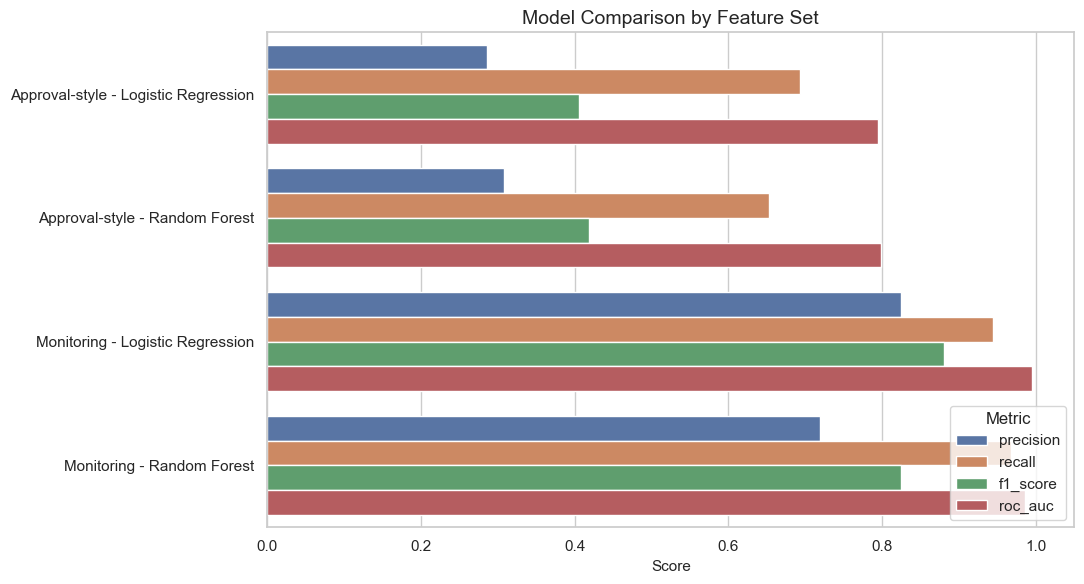

In [13]:
plt.figure(figsize=(11, 6))
plot_df = metrics_df.melt(
    id_vars=["feature_set", "model"],
    value_vars=["precision", "recall", "f1_score", "roc_auc"],
    var_name="metric",
    value_name="score",
)
plot_df["model_label"] = plot_df["feature_set"] + " - " + plot_df["model"]

sns.barplot(data=plot_df, x="score", y="model_label", hue="metric")
plt.title("Model Comparison by Feature Set")
plt.xlabel("Score")
plt.ylabel("")
plt.xlim(0, 1.05)
plt.legend(title="Metric", loc="lower right")
plt.tight_layout()
plt.savefig(figures_dir / "model_comparison_metrics.png", dpi=160)
plt.show()


## 11. Select Final Monitoring Model and Confusion Matrix

For default-risk monitoring, I prioritize recall for the default class, then F1-score, ROC-AUC, lower false negatives and precision.

The final model is selected from the Monitoring feature set because it is the model used for active loan review.


In [14]:
monitoring_candidates = metrics_df[metrics_df["feature_set"] == "Monitoring"].copy()
best_row = (
    monitoring_candidates
    .sort_values(
        ["recall", "f1_score", "roc_auc", "false_negatives", "precision"],
        ascending=[False, False, False, True, False],
    )
    .iloc[0]
)

best_feature_set = best_row["feature_set"]
best_model_name = best_row["model"]
best_output = model_outputs[(best_feature_set, best_model_name)]
best_model = best_output["pipeline"]
best_prediction = best_output["prediction"]
best_numeric = best_output["numeric_features"]
best_categorical = best_output["categorical_features"]

print("Selected feature set:", best_feature_set)
print("Selected model:", best_model_name)
print("Selection priority: recall, F1-score, ROC-AUC, fewer false negatives, then precision")

cm = confusion_matrix(best_prediction["y_test"], best_prediction["y_pred"], labels=[0, 1])
cm_df = pd.DataFrame(cm, index=["Actual Not Default", "Actual Default"], columns=["Predicted Not Default", "Predicted Default"])
cm_df.to_csv(tables_dir / "best_model_confusion_matrix.csv")
cm_df


Selected feature set: Monitoring
Selected model: Random Forest
Selection priority: recall, F1-score, ROC-AUC, fewer false negatives, then precision


,Predicted Not Default,Predicted Default
Actual Not Default,2457,142
Actual Default,12,363


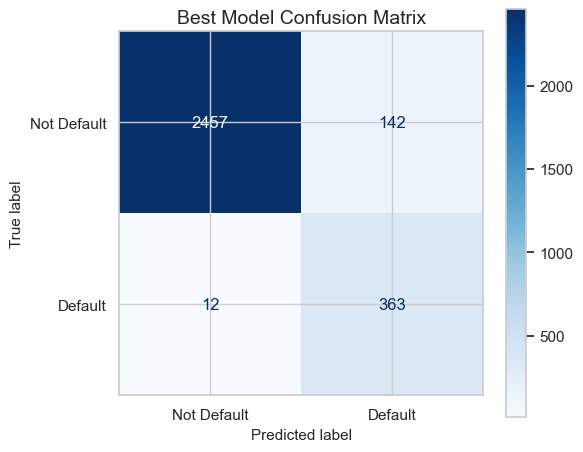

In [15]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    best_prediction["y_test"],
    best_prediction["y_pred"],
    display_labels=["Not Default", "Default"],
    cmap="Blues",
    ax=ax,
)
plt.title("Best Model Confusion Matrix")
plt.tight_layout()
plt.savefig(figures_dir / "best_model_confusion_matrix.png", dpi=160)
plt.show()


### Confusion Matrix Result

The confusion matrix shows how many defaults were caught and how many normal loans were incorrectly flagged. For banking risk, recall matters because missing a risky loan can be costly.


## 12. ROC Curve


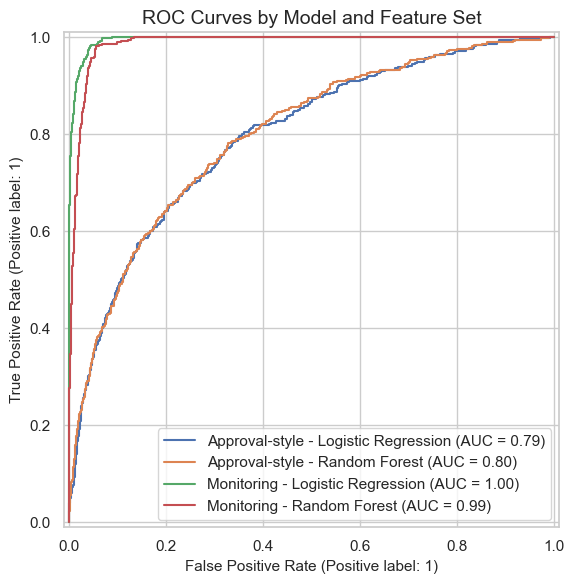

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))

for (feature_set_name, model_name), output in model_outputs.items():
    prediction = output["prediction"]
    RocCurveDisplay.from_predictions(
        prediction["y_test"],
        prediction["y_probability"],
        name=f"{feature_set_name} - {model_name}",
        ax=ax,
    )

plt.title("ROC Curves by Model and Feature Set")
plt.tight_layout()
plt.savefig(figures_dir / "roc_curves.png", dpi=160)
plt.show()


### ROC Result

The ROC curve shows how well the models separate default and non-default loans across different thresholds.


## 13. Final Model Feature Influence

If the selected final model is Random Forest, I use feature importance. If Logistic Regression is selected, I use coefficient strength.


In [17]:
final_model = best_model
preprocessor = final_model.named_steps["preprocess"]
estimator = final_model.named_steps["model"]

transformed_feature_names = preprocessor.get_feature_names_out()


def get_original_feature_name(transformed_name):
    if transformed_name.startswith("num__"):
        return transformed_name.replace("num__", "")

    if transformed_name.startswith("cat__"):
        clean_name = transformed_name.replace("cat__", "")
        for column in best_categorical:
            if clean_name.startswith(column + "_"):
                return column

    return transformed_name


if best_model_name == "Random Forest":
    influence_df = pd.DataFrame(
        {
            "transformed_feature": transformed_feature_names,
            "importance": estimator.feature_importances_,
        }
    )
    influence_df["feature"] = influence_df["transformed_feature"].apply(get_original_feature_name)

    feature_importance = (
        influence_df.groupby("feature", as_index=False)["importance"]
        .sum()
        .sort_values("importance", ascending=False)
    )
    feature_importance["importance_pct"] = (feature_importance["importance"] / feature_importance["importance"].sum() * 100).round(2)
    feature_importance.to_csv(tables_dir / "random_forest_feature_importance.csv", index=False)
else:
    influence_df = pd.DataFrame(
        {
            "transformed_feature": transformed_feature_names,
            "coefficient": estimator.coef_[0],
        }
    )
    influence_df["feature"] = influence_df["transformed_feature"].apply(get_original_feature_name)
    influence_df["absolute_coefficient"] = influence_df["coefficient"].abs()

    feature_importance = (
        influence_df.groupby("feature", as_index=False)["absolute_coefficient"]
        .sum()
        .rename(columns={"absolute_coefficient": "importance"})
        .sort_values("importance", ascending=False)
    )
    feature_importance["importance_pct"] = (feature_importance["importance"] / feature_importance["importance"].sum() * 100).round(2)
    feature_importance.to_csv(tables_dir / "logistic_regression_feature_influence.csv", index=False)

feature_importance.head(15)


,feature,importance,importance_pct
13,days_past_due,0.389851,38.99
32,risk_band,0.232016,23.20
28,missed_payments_12m,0.167840,16.78
14,debt_to_income_ratio,0.039033,3.90
10,credit_score,0.033430,3.34
24,loan_to_income_ratio,0.016483,1.65
26,loan_type,0.014523,1.45
21,loan_amount,0.012796,1.28
22,loan_purpose,0.011542,1.15
23,loan_term_months,0.007950,0.79


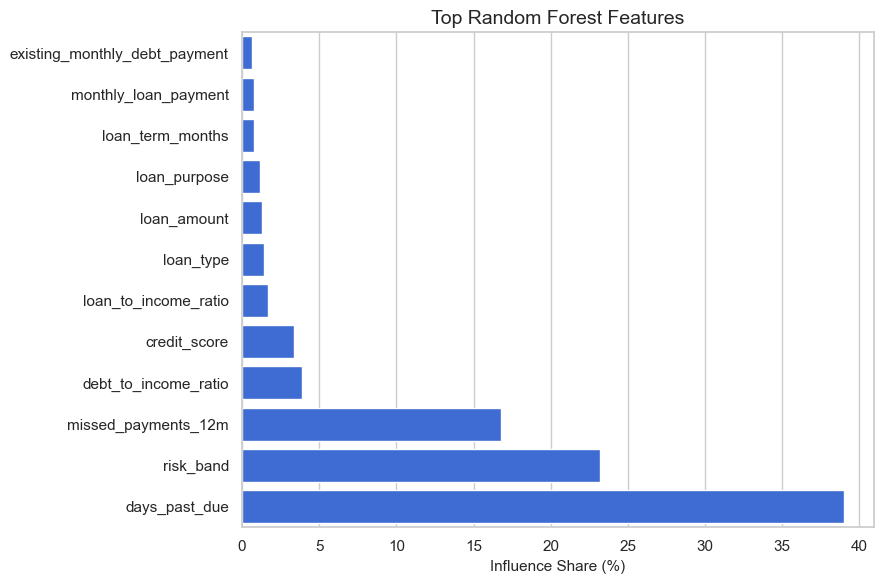

In [18]:
top_features = feature_importance.head(12).sort_values("importance")
figure_name = "random_forest_feature_importance.png" if best_model_name == "Random Forest" else "logistic_regression_feature_influence.png"
figure_title = "Top Random Forest Features" if best_model_name == "Random Forest" else "Top Logistic Regression Feature Influence"

plt.figure(figsize=(9, 6))
sns.barplot(data=top_features, x="importance_pct", y="feature", color="#2563eb")
plt.title(figure_title)
plt.xlabel("Influence Share (%)")
plt.ylabel("")
plt.tight_layout()
plt.savefig(figures_dir / figure_name, dpi=160)
plt.show()


### Feature Influence Result

The top features should match the earlier risk analysis. Strong monitoring features are expected to include repayment-warning fields, DTI, credit score, loan amount and other financial strength indicators.


## 14. High-Risk Loan List

This creates a small table of loans with the highest predicted default probability from the selected final monitoring model.


In [19]:
X_test = best_prediction["X_test"].copy()
y_test = best_prediction["y_test"].copy()
y_probability = best_prediction["y_probability"]
y_pred = best_prediction["y_pred"]

selected_rows = loan_df.loc[X_test.index, [
    "loan_id",
    "customer_id",
    "loan_type",
    "loan_amount",
    "annual_income",
    "credit_score",
    "debt_to_income_ratio",
    "missed_payments_12m",
    "days_past_due",
    "risk_band",
    "repayment_status",
    "default_flag",
]].copy()

selected_rows["predicted_default"] = y_pred
selected_rows["default_probability"] = y_probability
selected_rows["default_probability_pct"] = (selected_rows["default_probability"] * 100).round(2)

high_risk_loans = selected_rows.sort_values("default_probability", ascending=False).head(25)
high_risk_loans.to_csv(tables_dir / "high_risk_loan_predictions.csv", index=False)
high_risk_loans.head(10)


,loan_id,customer_id,loan_type,loan_amount,annual_income,credit_score,debt_to_income_ratio,missed_payments_12m,days_past_due,risk_band,repayment_status,default_flag,predicted_default,default_probability,default_probability_pct
314,LOAN000315,CUST02672,Business Loan,2341729.83,603168.32,632.0,1.288,9,180,High,Defaulted,1,1,0.959841,95.98
11080,LOAN011081,CUST10316,Business Loan,1784243.35,887050.88,625.0,1.070,6,180,High,Defaulted,1,1,0.957901,95.79
7329,LOAN007330,CUST00442,Business Loan,1314975.12,449909.30,576.0,1.320,7,180,High,Defaulted,1,1,0.954005,95.40
4353,LOAN004354,CUST03949,Business Loan,3346476.12,1223734.15,632.0,0.995,7,141,High,Written Off,1,1,0.953507,95.35
7183,LOAN007184,CUST07198,Business Loan,3634083.59,1231648.68,616.0,1.131,6,176,High,Defaulted,1,1,0.952541,95.25
5226,LOAN005227,CUST03821,Business Loan,3647290.26,1054873.43,646.0,1.348,7,180,High,Defaulted,1,1,0.951557,95.16
11259,LOAN011260,CUST09125,Business Loan,2093032.66,635804.99,644.0,1.142,7,147,High,Defaulted,1,1,0.950830,95.08
5056,LOAN005057,CUST00955,Business Loan,2687352.84,820013.75,631.0,0.866,6,180,High,Defaulted,1,1,0.949701,94.97
2549,LOAN002550,CUST05173,Business Loan,4775273.10,1428825.57,633.0,1.002,9,180,High,Defaulted,1,1,0.948173,94.82
4997,LOAN004998,CUST09831,Business Loan,2319752.25,980131.19,619.0,0.836,8,180,High,Written Off,1,1,0.947830,94.78


### High-Risk List Result

The high-risk list is not a final lending decision. It is a monitoring list that helps identify which active loans should be reviewed first.


## 15. Business Interpretation


In [20]:
test_result = selected_rows.copy()
test_result["probability_group"] = pd.qcut(
    test_result["default_probability"].rank(method="first"),
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"],
)

probability_group_summary = (
    test_result.groupby("probability_group", observed=True)
    .agg(
        loans=("loan_id", "count"),
        actual_defaults=("default_flag", "sum"),
        average_probability=("default_probability", "mean"),
        total_exposure=("loan_amount", "sum"),
    )
    .reset_index()
)
probability_group_summary["actual_default_rate"] = (probability_group_summary["actual_defaults"] / probability_group_summary["loans"] * 100).round(2)
probability_group_summary["average_probability_pct"] = (probability_group_summary["average_probability"] * 100).round(2)
probability_group_summary["total_exposure_crore"] = (probability_group_summary["total_exposure"] / 10_000_000).round(2)
probability_group_summary = probability_group_summary.drop(columns=["average_probability", "total_exposure"])
probability_group_summary.to_csv(tables_dir / "model_probability_group_summary.csv", index=False)
probability_group_summary


,probability_group,loans,actual_defaults,actual_default_rate,average_probability_pct,total_exposure_crore
0,Very Low,595,0,0.00,0.79,49.88
1,Low,595,0,0.00,1.67,73.03
2,Medium,594,0,0.00,5.40,144.57
3,High,595,5,0.84,16.21,157.31
4,Very High,595,370,62.18,74.85,182.01


### Business Result

The probability groups convert model output into a simple risk-ranking view. The bank can use this to review the highest-risk active loans first instead of treating every loan the same.


## 16. Final Summary

This section builds a default-risk monitoring model for the loan portfolio. The target is `default_flag`, where `1` means the loan is marked as defaulted and `0` means it is not defaulted.

### 1. Split Used

I used a customer-wise split so the same borrower does not appear in both training and testing.

| Check | Result |
|---|---:|
| Training loan rows | 8,937 |
| Testing loan rows | 2,974 |
| Training customers | 7,709 |
| Testing customers | 2,570 |
| Customer overlap | 0 |
| Training default rate | 12.34% |
| Testing default rate | 12.61% |

### 2. Tuning Used

I used one tuning method: `RandomizedSearchCV` for Random Forest. Tuning was done only on the training customers using grouped cross-validation, so the final test customers stayed untouched.

| Feature set | Best CV recall | Trees | Max depth | Min leaf | Max features |
|---|---:|---:|---|---:|---|
| Approval-style | 0.6319 | 200 | 6 | 10 | sqrt |
| Monitoring | 0.9791 | 500 | None | 20 | sqrt |

### 3. Model Comparison

| Feature set | Model | Accuracy | Precision | Recall | F1-score | ROC-AUC | False negatives | False positives |
|---|---|---:|---:|---:|---:|---:|---:|---:|
| Approval-style | Logistic Regression | 0.7431 | 0.2860 | 0.6933 | 0.4050 | 0.7949 | 115 | 649 |
| Approval-style | Random Forest | 0.7717 | 0.3086 | 0.6533 | 0.4192 | 0.7983 | 130 | 549 |
| Monitoring | Logistic Regression | 0.9677 | 0.8252 | 0.9440 | 0.8806 | 0.9950 | 21 | 75 |
| Monitoring | Random Forest | 0.9482 | 0.7188 | 0.9680 | 0.8250 | 0.9861 | 12 | 142 |

### 4. Final Model

The final selected model is the **Monitoring Random Forest**. It catches `363` out of `375` actual default loans and misses `12`. I selected it because this project is about default-risk monitoring, where missing risky loans is more costly than reviewing some extra flagged loans.

### 5. Main Drivers

| Feature | Importance |
|---|---:|
| `days_past_due` | 38.99% |
| `risk_band` | 23.20% |
| `missed_payments_12m` | 16.78% |
| `debt_to_income_ratio` | 3.90% |
| `credit_score` | 3.34% |

These drivers make sense because default risk is mainly linked with repayment delay, missed payments, debt pressure and credit quality.

### 6. Business Use

The model should be used as a review-priority tool. It can help the bank focus on loans with the highest predicted default probability first. It should not be used as an automatic loan-approval system because the monitoring feature set includes active repayment-warning fields like missed payments and days past due.
